# Exemplar: Run simple linear regression

## Step 1: Imports

In [1]:
# Import relevant Python libraries and modules

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols
import statsmodels.api as sm

In [2]:
data = pd.read_csv("marketing_sales_data.csv")

## Step 2. Data Exploration

In [3]:
data.head(10)

,TV,Radio,Social Media,Influencer,Sales
0,Low,1.218354,1.270444,Micro,90.054222
1,Medium,14.949791,0.274451,Macro,222.741668
2,Low,10.377258,0.061984,Mega,102.774790
3,High,26.469274,7.070945,Micro,328.239378
4,High,36.876302,7.618605,Mega,351.807328
5,High,25.561910,5.459718,Micro,261.966812
6,High,37.263819,6.886535,Nano,349.861575
7,Low,13.187256,2.766352,Macro,140.415286
8,High,29.520170,2.333157,Nano,264.592233
9,Low,3.773287,0.135074,Nano,55.674214


### To get a sense of how large the data is, identify the number of rows and the number of columns in the data.

In [4]:
data.shape

(572, 5)

In [5]:
# Step 1. Start with .isna() to get booleans indicating whether each value in the data is missing
data.isna()

,TV,Radio,Social Media,Influencer,Sales
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
567,False,False,False,False,False
568,False,False,False,False,False
569,False,False,False,False,False
570,False,False,False,False,False


In [6]:
# Step 1. Start with .isna() to get booleans indicating whether each value in the data is missing
# Step 2. Use .any(axis=1) to get booleans indicating whether there are any missing values along the columns in each row

data.isna().any(axis=1)

0      False
1      False
2      False
3      False
4      False
       ...  
567    False
568    False
569    False
570    False
571    False
Length: 572, dtype: bool

In [7]:
# Step 1. Start with .isna() to get booleans indicating whether each value in the data is missing
# Step 2. Use .any(axis=1) to get booleans indicating whether there are any missing values along the columns in each row
# Step 3. Use .sum() to get the number of rows that contain missing values
data.isna().any(axis=1).sum()

np.int64(3)

### Drop the rows that contain missing values.

In [8]:
# Step 1. Use .dropna(axis=0) to indicate that you want rows which contain missing values to be dropped
# Step 2. To update the DataFrame, reassign it to the result

data = data.dropna(axis=0)

In [9]:
# Check to make sure that the data does not contain any rows with missing values now

# Step 1. Start with .isna() to get booleans indicating whether each value in the data is missing
# Step 2. Use .any(axis=1) to get booleans indicating whether there are any missing values along the columns in each row
# Step 3. Use .sum() to get the number of rows that contain missing values

data.isna().any(axis=1).sum()

0

### Check model assumptions.


### Start by creating a plot of pairwise relationships in the data.
This will help you visualize the relationships between variables in the data and help you check model assumptions. 

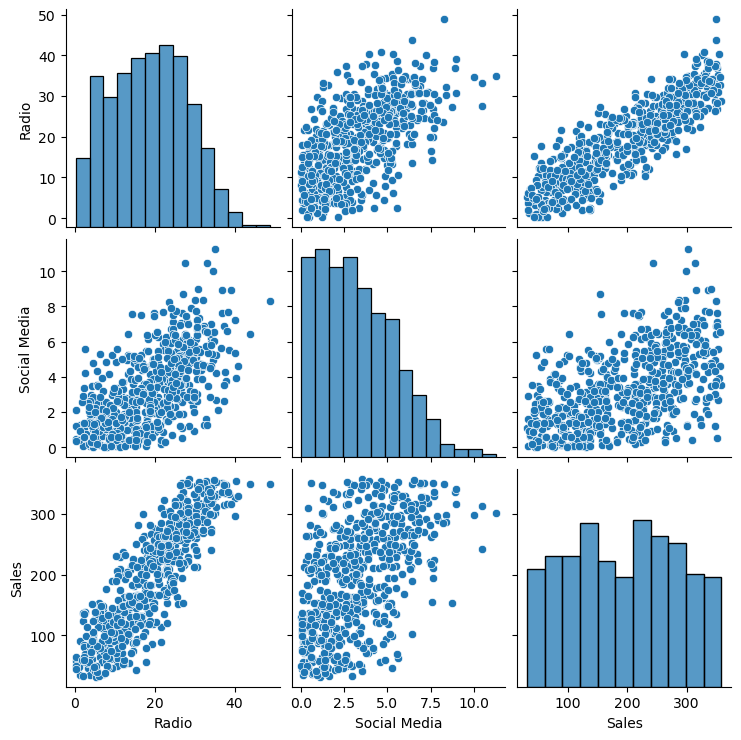

In [8]:
# Create plot of pairwise relationships
sns.pairplot(data)

## Step 3. Model Building

In [9]:
# Select relevant columns
# Save resulting DataFrame in a separate variable to prepare for regression

ols_data = data[["Radio", "Sales"]]

### Display the first 10 rows of the new DataFrame to ensure it is accurate.

In [10]:
# Display first 10 rows of the new DataFrame

ols_data.head(10)

,Radio,Sales
0,1.218354,90.054222
1,14.949791,222.741668
2,10.377258,102.774790
3,26.469274,328.239378
4,36.876302,351.807328
5,25.561910,261.966812
6,37.263819,349.861575
7,13.187256,140.415286
8,29.520170,264.592233
9,3.773287,55.674214


### Write the linear regression formula for modeling the relationship between the two variables of interest.

In [11]:
# Write the linear regression formula
# Save it in a variable

ols_formula = "Sales ~ Radio"

### Implement the Ordinary Least Squares (OLS) approach for linear regression.

In [12]:
# Implement OLS

OLS = ols(formula = ols_formula, data = ols_data)

### Create a linear regression model for the data and fit the model to the data.

In [13]:
# Fit the model to the data
# Save the fitted model in a variable

model = OLS.fit()

## Step 4. Results and Evaluation

### Get a summary of the results from the model.

In [14]:
# Get summary of results

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.758
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1781.
Date:                Fri, 03 Apr 2026   Prob (F-statistic):          2.96e-177
Time:                        20:40:59   Log-Likelihood:                -2971.5
No. Observations:                 570   AIC:                             5947.
Df Residuals:                     568   BIC:                             5956.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     41.4488      4.061     10.206      0.000      33.472      49.426
Radio          8.1799      0.194     42.206      0.000       7.799       8.561
==============================================================================
Omnibus:                        2.272   Durbin-Watson:                   1.881
Prob(Omnibus):                  0.321   Jarque-Bera (JB):                2.236
Skew:                          -0.105   Prob(JB):                        0.327
Kurtosis:                       2.776   Cond. No.                         45.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Finish checking model assumptions.

Now that you've built the linear regression model and fit it to the data, you can finish checking the model assumptions. This will help confirm your findings.

### Plot the OLS data with the best fit regression line.

<Axes: xlabel='Radio', ylabel='Sales'>

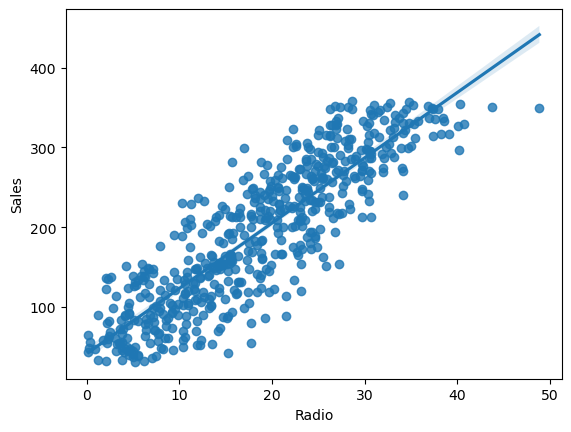

In [15]:
# Plot the OLS data with the best fit regression line

sns.regplot(x = "Radio", y = "Sales", data = ols_data)

### Check the normality assumption.

To get started, get the residuals from the model.

In [16]:
# Get the residuals from the model

residuals = model.resid

Visualize the distribution of the residuals.

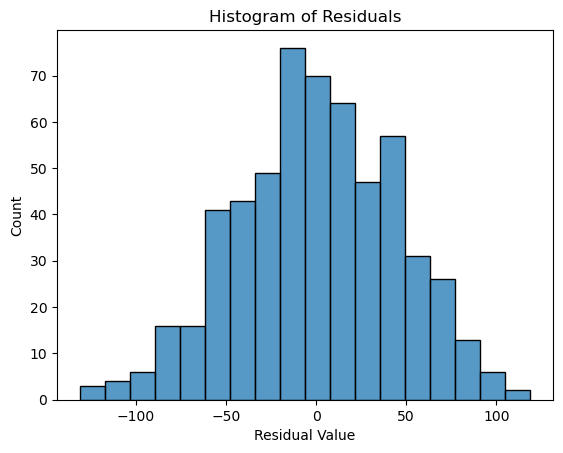

In [17]:
# Visualize the distribution of the residuals

fig = sns.histplot(residuals)
fig.set_xlabel("Residual Value")
fig.set_title("Histogram of Residuals")
plt.show()

### Create a Q-Q plot to confirm the assumption of normality.

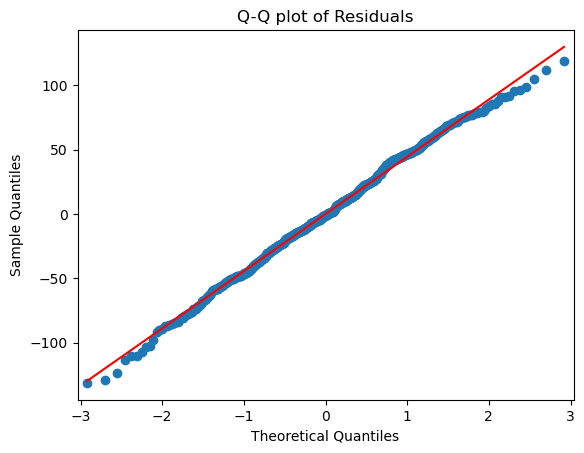

In [18]:
# Create a Q-Q plot 

sm.qqplot(residuals, line='s')
plt.title("Q-Q plot of Residuals")
plt.show()

### Check the assumptions of independent observation and homoscedasticity.

Start by getting the fitted values from the model.

In [19]:
# Get fitted values

fitted_values = model.predict(ols_data["Radio"])

Create a scatterplot of the residuals against the fitted values.

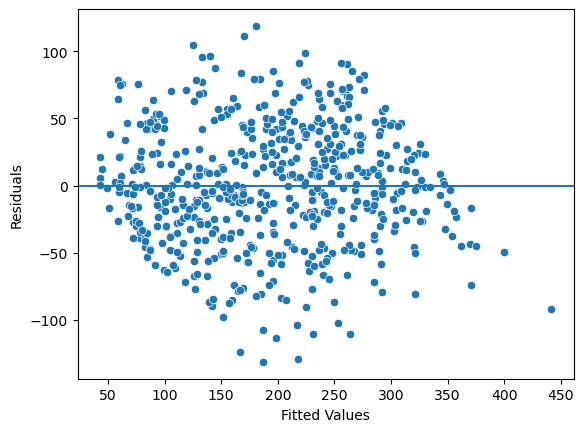

In [20]:
# Create a scatterplot of residuals against fitted values

fig = sns.scatterplot(x=fitted_values, y=residuals)
fig.axhline(0)
fig.set_xlabel("Fitted Values")
fig.set_ylabel("Residuals")
plt.show()